In [9]:
import json
from matplotlib.lines import Line2D
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [10]:
ROLLING_WINDOW = 20
FAINT_ALPHA = 0.25
FAINT_LINEWIDTH = 1.5
SOLID_LINEWIDTH = 2.5
MARKER_SIZE = 100

def find_project_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root starting from '{current}'")

PROJECT_ROOT = find_project_root()

OUTPUT_DIRECTORY = PROJECT_ROOT / "result" / "MedVLM-R1" / "bias_field_compare_candidates"
RESULT_FILE_PATH = OUTPUT_DIRECTORY / "candidate_comparison.jsonl"
HISTORY_FILE_PATH = OUTPUT_DIRECTORY / "history.csv"
IMAGE_DIRECTORY = OUTPUT_DIRECTORY / "images"


In [11]:
def load_available_samples(file_path):
    samples = {}

    with file_path.open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if not line:
                continue

            sample = json.loads(line)

            if sample.get("comparison_available") is True:
                samples[sample["question_id"]] = sample

    return samples

samples = load_available_samples(RESULT_FILE_PATH)
qids = set(samples)

history = pd.read_csv(HISTORY_FILE_PATH)

history["attack_success"] = history["attack_success"].astype("boolean")

filtered_history = history[history["question_id"].isin(qids)].copy()
filtered_history = filtered_history.sort_values(["question_id", "step"])

In [12]:
metrics = ["loss", "mse", "psnr", "ssim"]

first_success = (
    filtered_history[
        filtered_history["attack_success"].fillna(False)
    ]
    .sort_values(["question_id", "step"])
    .groupby("question_id", as_index=False)
    .first()
)

first_success = first_success[
    [
        "question_id",
        "step",
        "loss",
        "mse",
        "psnr",
        "ssim",
    ]
].rename(
    columns={
        "step": "first_success_step",
        "loss": "first_success_loss",
        "mse": "first_success_mse",
        "psnr": "first_success_psnr",
        "ssim": "first_success_ssim",
    }
)

comparison_df = pd.DataFrame(samples.values()).merge(first_success, on="question_id", how="left")

total = len(comparison_df)

same_checkpoint = (
    comparison_df["first_success_step"]
    == comparison_df["low_step"]
)
different_checkpoint = ~same_checkpoint

same_count = same_checkpoint.sum()
different_count = different_checkpoint.sum()

step_earlier = comparison_df["first_success_step"] < comparison_df["low_step"]
step_later = comparison_df["first_success_step"] > comparison_df["low_step"]

loss_lower = (comparison_df["first_success_loss"] < comparison_df["low_loss"]) & different_checkpoint
loss_higher = (comparison_df["first_success_loss"] > comparison_df["low_loss"]) & different_checkpoint
loss_equal = (comparison_df["first_success_loss"] == comparison_df["low_loss"]) & different_checkpoint

mse_lower = (comparison_df["first_success_mse"] < comparison_df["low_mse"]) & different_checkpoint
mse_higher = (comparison_df["first_success_mse"] > comparison_df["low_mse"]) & different_checkpoint
mse_equal = (comparison_df["first_success_mse"] == comparison_df["low_mse"]) & different_checkpoint

psnr_higher = (comparison_df["first_success_psnr"] > comparison_df["low_psnr"]) & different_checkpoint
psnr_lower = (comparison_df["first_success_psnr"] < comparison_df["low_psnr"]) & different_checkpoint
psnr_equal = (comparison_df["first_success_psnr"] == comparison_df["low_psnr"]) & different_checkpoint

ssim_higher = (comparison_df["first_success_ssim"] > comparison_df["low_ssim"]) & different_checkpoint
ssim_lower = (comparison_df["first_success_ssim"] < comparison_df["low_ssim"]) & different_checkpoint
ssim_equal = (comparison_df["first_success_ssim"] == comparison_df["low_ssim"]) & different_checkpoint

print("Comparison of first-success checkpoint against low-loss checkpoint")
print(f"Number of samples: {total}\n")

print("Candidate checkpoint:")
print(f"  same checkpoint:      {same_count:2}/{total} ({same_count / total * 100:.1f}%)")
print(f"  different checkpoint: {different_count:2}/{total} ({different_count / total * 100:.1f}%)")
print()

print("Step of first-success checkpoint:")
print(f"  earlier than low-loss: {step_earlier.sum():2}/{total} ({step_earlier.mean() * 100:.1f}%)")
print(f"  same as low-loss:      {same_checkpoint.sum():2}/{total} ({same_checkpoint.mean() * 100:.1f}%)")
print(f"  later than low-loss:   {step_later.sum():2}/{total} ({step_later.mean() * 100:.1f}%)")
print()

print(f"Metrics among the {different_count} samples with different checkpoints:\n")

print("Loss of first-success checkpoint (lower is better):")
print(f"  lower than low-loss:  {loss_lower.sum():2}/{different_count}")
print(f"  equal to low-loss:    {loss_equal.sum():2}/{different_count}")
print(f"  higher than low-loss: {loss_higher.sum():2}/{different_count}")
print()

print("MSE of first-success checkpoint (lower is better):")
print(f"  lower than low-loss:  {mse_lower.sum():2}/{different_count}")
print(f"  equal to low-loss:    {mse_equal.sum():2}/{different_count}")
print(f"  higher than low-loss: {mse_higher.sum():2}/{different_count}")
print()

print("PSNR of first-success checkpoint (higher is better):")
print(f"  higher than low-loss: {psnr_higher.sum():2}/{different_count}")
print(f"  equal to low-loss:    {psnr_equal.sum():2}/{different_count}")
print(f"  lower than low-loss:  {psnr_lower.sum():2}/{different_count}")
print()

print("SSIM of first-success checkpoint (higher is better):")
print(f"  higher than low-loss: {ssim_higher.sum():2}/{different_count}")
print(f"  equal to low-loss:    {ssim_equal.sum():2}/{different_count}")
print(f"  lower than low-loss:  {ssim_lower.sum():2}/{different_count}")

Comparison of first-success checkpoint against low-loss checkpoint
Number of samples: 50

Candidate checkpoint:
  same checkpoint:      36/50 (72.0%)
  different checkpoint: 14/50 (28.0%)

Step of first-success checkpoint:
  earlier than low-loss: 14/50 (28.0%)
  same as low-loss:      36/50 (72.0%)
  later than low-loss:    0/50 (0.0%)

Metrics among the 14 samples with different checkpoints:

Loss of first-success checkpoint (lower is better):
  lower than low-loss:   0/14
  equal to low-loss:     0/14
  higher than low-loss: 14/14

MSE of first-success checkpoint (lower is better):
  lower than low-loss:  13/14
  equal to low-loss:     0/14
  higher than low-loss:  1/14

PSNR of first-success checkpoint (higher is better):
  higher than low-loss: 13/14
  equal to low-loss:     0/14
  lower than low-loss:   1/14

SSIM of first-success checkpoint (higher is better):
  higher than low-loss: 14/14
  equal to low-loss:     0/14
  lower than low-loss:   0/14


## Loss

In [13]:
question_ids = sorted(
    filtered_history["question_id"].unique(),
    key=lambda question_id: int(question_id.split(":")[-1]),
)

combined_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=len(question_ids),
    step=1,
    description="Sample:",
    continuous_update=False,
    style={"description_width": "initial"},
)

combined_input = widgets.BoundedIntText(
    value=1,
    min=1,
    max=len(question_ids),
    step=1,
    description="",
    layout=widgets.Layout(width="80px"),
)

widgets.jslink(
    (combined_slider, "value"),
    (combined_input, "value"),
)

combined_selector = widgets.HBox([
    combined_slider,
    combined_input,
])

combined_output = widgets.Output()


def add_event_lines(
    axis,
    low_step,
    high_step,
    first_success_step,
    show_labels=True,
):
    axis.axvline(
        x=low_step,
        color="black",
        linestyle="--",
        linewidth=1.4,
        zorder=4,
    )

    axis.axvline(
        x=high_step,
        color="black",
        linestyle="-.",
        linewidth=1.4,
        zorder=4,
    )

    if first_success_step is not None:
        axis.axvline(
            x=first_success_step,
            color="red",
            linestyle=":",
            linewidth=1.5,
            alpha=0.8,
            zorder=4,
        )

    if show_labels:
        axis.text(
            low_step,
            0.98,
            "Low",
            transform=axis.get_xaxis_transform(),
            rotation=90,
            horizontalalignment="right",
            verticalalignment="top",
            fontsize=9,
            color="black",
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85,
                "pad": 1.5,
            },
            zorder=5,
        )

        axis.text(
            high_step,
            0.98,
            "High",
            transform=axis.get_xaxis_transform(),
            rotation=90,
            horizontalalignment="left",
            verticalalignment="top",
            fontsize=9,
            color="black",
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85,
                "pad": 1.5,
            },
            zorder=5,
        )

        if first_success_step is not None:
            axis.text(
                first_success_step,
                0.98,
                "First success",
                transform=axis.get_xaxis_transform(),
                rotation=90,
                horizontalalignment="left",
                verticalalignment="top",
                fontsize=9,
                color="red",
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.85,
                    "pad": 1.5,
                },
                zorder=5,
            )


def plot_selected_attack_metrics(change=None):
    sample_number = combined_slider.value
    question_id = question_ids[sample_number - 1]

    sample_history = (
        filtered_history.loc[
            filtered_history["question_id"] == question_id
        ]
        .copy()
        .sort_values("step")
    )

    image_metric_history = sample_history.loc[
        (sample_history["step"] > 1)
        & np.isfinite(sample_history["mse"])
        & np.isfinite(sample_history["psnr"])
        & np.isfinite(sample_history["ssim"])
    ].copy()

    sample = samples[question_id]

    low_step = sample["low_step"]
    high_step = sample["high_step"]

    successful_rows = sample_history.loc[
        sample_history["attack_success"].eq(True)
    ]

    first_success_step = (
        int(successful_rows["step"].min())
        if not successful_rows.empty
        else None
    )

    with combined_output:
        combined_output.clear_output(wait=True)

        with plt.ioff():
            fig, axes = plt.subplots(
                4,
                1,
                figsize=(15, 15),
                sharex=True,
            )

        # --------------------------------------------------
        # Model loss
        # --------------------------------------------------
        smoothed_loss = sample_history["loss"].rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1,
        ).mean()

        axes[0].plot(
            sample_history["step"],
            sample_history["loss"],
            color="indigo",
            alpha=0.2,
            linewidth=0.8,
            label="Raw loss",
        )

        axes[0].plot(
            sample_history["step"],
            smoothed_loss,
            color="indigo",
            linewidth=2,
            label="Smoothed loss",
        )

        low_row = sample_history.loc[
            sample_history["step"].eq(low_step)
        ]

        high_row = sample_history.loc[
            sample_history["step"].eq(high_step)
        ]

        if not low_row.empty:
            axes[0].scatter(
                low_step,
                low_row.iloc[0]["loss"],
                marker="o",
                s=MARKER_SIZE,
                color="indigo",
                edgecolors="black",
                linewidths=0.8,
                zorder=6,
            )

        if not high_row.empty:
            axes[0].scatter(
                high_step,
                high_row.iloc[0]["loss"],
                marker="^",
                s=MARKER_SIZE,
                color="indigo",
                edgecolors="black",
                linewidths=0.8,
                zorder=6,
            )

        add_event_lines(
            axes[0],
            low_step,
            high_step,
            first_success_step,
            show_labels=True,
        )

        axes[0].set_ylabel("Model loss")
        axes[0].set_title("Attack objective")
        axes[0].set_ylim(bottom=0)
        axes[0].grid(alpha=0.3)

        # --------------------------------------------------
        # Image-quality metrics
        # --------------------------------------------------
        image_metrics = [
            ("mse", "MSE", "Mean squared error"),
            ("psnr", "PSNR (dB)", "Peak signal-to-noise ratio"),
            ("ssim", "SSIM", "Structural similarity"),
        ]

        for axis, (column, ylabel, title) in zip(
            axes[1:],
            image_metrics,
        ):
            axis.plot(
                image_metric_history["step"],
                image_metric_history[column],
                color="indigo",
                linewidth=2,
                label="Metric value",
            )

            add_event_lines(
                axis,
                low_step,
                high_step,
                first_success_step,
                show_labels=True,
            )

            axis.set_ylabel(ylabel)
            axis.set_title(title)
            axis.grid(alpha=0.3)

        axes[-1].set_xlabel("Optimisation step")

        axes[1].ticklabel_format(
            axis="y",
            style="sci",
            scilimits=(0, 0),
        )

        sample_id = question_id.split(":")[-1]

        success_text = (
            f"first success at step {first_success_step}"
            if first_success_step is not None
            else "no successful attack recorded"
        )

        fig.suptitle(
            f"Attack objective and image quality\n"
            f"Sample {sample_number}/{len(question_ids)} — "
            f"{sample_id} — {success_text}",
            fontsize=15,
        )

        legend_handles = [
            Line2D(
                [0],
                [0],
                color="indigo",
                linewidth=2,
                label="Metric or smoothed loss",
            ),
            Line2D(
                [0],
                [0],
                color="indigo",
                linewidth=0.8,
                alpha=0.2,
                label="Raw model loss",
            ),
            Line2D(
                [0],
                [0],
                color="black",
                linestyle="--",
                linewidth=1.4,
                label=f"Low-loss candidate (step {low_step})",
            ),
            Line2D(
                [0],
                [0],
                color="black",
                linestyle="-.",
                linewidth=1.4,
                label=f"High-loss candidate (step {high_step})",
            ),
        ]

        if first_success_step is not None:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="red",
                    linestyle=":",
                    linewidth=1.5,
                    label=(
                        f"First attack success "
                        f"(step {first_success_step})"
                    ),
                )
            )

        axes[0].legend(
            handles=legend_handles,
            loc="best",
        )

        fig.tight_layout()
        # display(fig)
        # plt.close(fig)
        plt.show()

# combined_slider.observe(
#     plot_selected_attack_metrics,
#     names="value",
# )

# if "combined_view" in globals():
#     combined_view.close()

# combined_view = widgets.VBox([combined_selector, combined_output])
# display(combined_view)
# plot_selected_attack_metrics()
combined_slider.observe(
    plot_selected_attack_metrics,
    names="value",
)

display(combined_selector, combined_output)
plot_selected_attack_metrics()

Output()

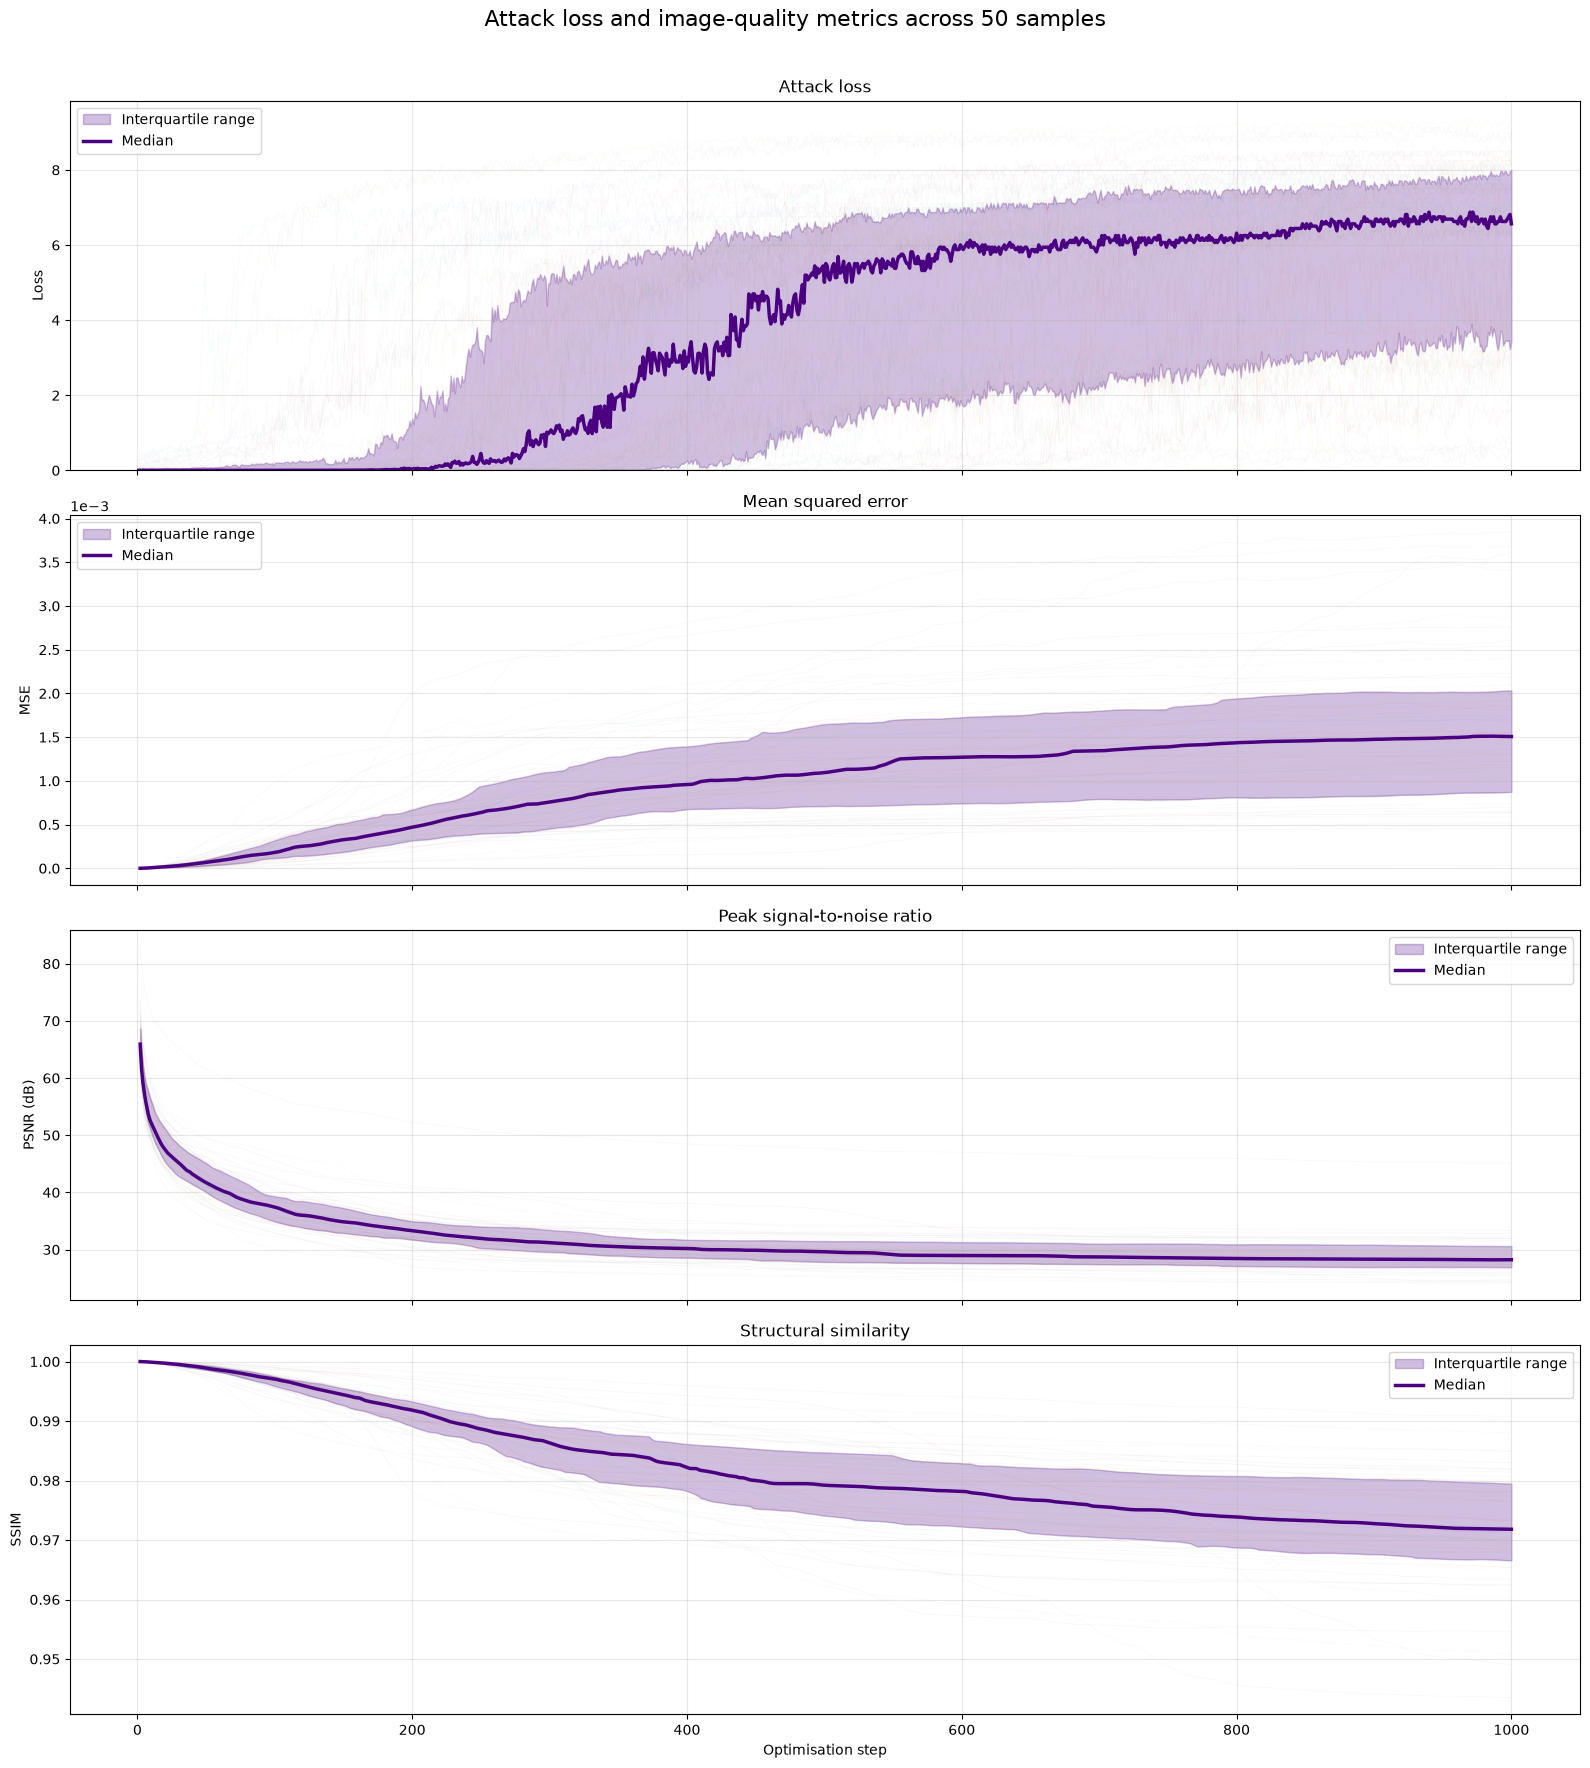

In [14]:
PLOT_METRICS = [
    ("loss", "Loss", "Attack loss"),
    ("mse", "MSE", "Mean squared error"),
    ("psnr", "PSNR (dB)", "Peak signal-to-noise ratio"),
    ("ssim", "SSIM", "Structural similarity"),
]

# Loss can use step 1, but image metrics cannot because PSNR is infinite.
loss_history = filtered_history.loc[
    np.isfinite(filtered_history["loss"])
].copy()

metric_history = filtered_history.loc[
    (filtered_history["step"] > 1)
    & np.isfinite(filtered_history["mse"])
    & np.isfinite(filtered_history["psnr"])
    & np.isfinite(filtered_history["ssim"])
].copy()

summaries = {}

# Loss summary
summaries["loss"] = (
    loss_history
    .groupby("step")["loss"]
    .agg(
        median="median",
        q1=lambda values: values.quantile(0.25),
        q3=lambda values: values.quantile(0.75),
    )
    .reset_index()
)

# Image-metric summaries
for column, _, _ in PLOT_METRICS[1:]:
    summaries[column] = (
        metric_history
        .groupby("step")[column]
        .agg(
            median="median",
            q1=lambda values: values.quantile(0.25),
            q3=lambda values: values.quantile(0.75),
        )
        .reset_index()
    )

fig, axes = plt.subplots(
    4,
    1,
    figsize=(16, 18),
    sharex=True,
)

for axis, (column, ylabel, title) in zip(
    axes,
    PLOT_METRICS,
):
    history_source = (
        loss_history
        if column == "loss"
        else metric_history
    )

    summary = summaries[column]

    # Individual trajectories in the background
    for question_id, sample_history in history_source.groupby(
        "question_id"
    ):
        sample_history = sample_history.sort_values("step")

        axis.plot(
            sample_history["step"],
            sample_history[column],
            alpha=0.04,
            linewidth=0.6,
        )

    # Interquartile range
    axis.fill_between(
        summary["step"],
        summary["q1"],
        summary["q3"],
        color="indigo",
        alpha=0.25,
        label="Interquartile range",
    )

    # Median
    axis.plot(
        summary["step"],
        summary["median"],
        color="indigo",
        linewidth=2.5,
        label="Median",
    )

    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.grid(alpha=0.3)
    axis.legend()

axes[-1].set_xlabel("Optimisation step")

# Scientific notation for MSE
axes[1].ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(0, 0),
)

# Keep loss non-negative
axes[0].set_ylim(bottom=0)

fig.suptitle(
    "Attack loss and image-quality metrics across 50 samples",
    fontsize=16,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97],
)

plt.show()

## Letter Probs

In [15]:
PROBABILITY_COLUMNS = ["prob_A", "prob_B", "prob_C", "prob_D"]

question_ids = sorted(
    filtered_history["question_id"].unique(),
    key=lambda qid: int(qid.split(":")[-1]),
)

probability_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=len(question_ids),
    step=1,
    description="Sample:",
    continuous_update=False,
    style={"description_width": "initial"},
)

probability_input = widgets.BoundedIntText(
    value=1,
    min=1,
    max=len(question_ids),
    step=1,
    description="",
    layout=widgets.Layout(width="80px"),
)

widgets.jslink(
    (probability_slider, "value"),
    (probability_input, "value"),
)

probability_selector = widgets.HBox([
    probability_slider,
    probability_input,
])

probability_output = widgets.Output()


def plot_selected_probabilities(change=None):
    sample_number = probability_slider.value
    question_id = question_ids[sample_number - 1]

    sample_history = (
        filtered_history.loc[
            filtered_history["question_id"] == question_id
        ]
        .copy()
        .sort_values("step")
    )

    sample = samples[question_id]

    correct_answer = sample["correct_answer"].upper()
    low_step = sample["low_step"]
    high_step = sample["high_step"]

    successful_rows = sample_history.loc[
        sample_history["attack_success"].eq(True)
    ]

    first_success_step = (
        int(successful_rows["step"].min())
        if not successful_rows.empty
        else None
    )

    with probability_output:
        probability_output.clear_output(wait=True)

        with plt.ioff():
            fig, axis = plt.subplots(figsize=(14, 6))

        plotted_lines = []

        for column in PROBABILITY_COLUMNS:
            answer = column[-1]

            smoothed_probability = sample_history[column].rolling(
                window=ROLLING_WINDOW,
                center=True,
                min_periods=1,
            ).mean()

            # Plot smoothed curve first to obtain its assigned colour
            line, = axis.plot(
                sample_history["step"],
                smoothed_probability,
                linewidth=2,
                label=answer,
            )

            line_color = line.get_color()
            plotted_lines.append(line)

            # Raw probability curve using the same colour
            axis.plot(
                sample_history["step"],
                sample_history[column],
                color=line_color,
                alpha=0.15,
                linewidth=0.8,
            )

        axis.axvline(
            x=low_step,
            color="black",
            linestyle="--",
            linewidth=1.4,
            zorder=4,
        )

        axis.axvline(
            x=high_step,
            color="black",
            linestyle="-.",
            linewidth=1.4,
            zorder=4,
        )

        if first_success_step is not None:
            axis.axvline(
                x=first_success_step,
                color="red",
                linestyle=":",
                linewidth=1.5,
                alpha=0.8,
                zorder=4,
            )

        axis.text(
            low_step,
            0.98,
            "Low",
            rotation=90,
            horizontalalignment="right",
            verticalalignment="top",
            fontsize=10,
            color="black",
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85,
                "pad": 1.5,
            },
            zorder=5,
        )

        axis.text(
            high_step,
            0.98,
            "High",
            rotation=90,
            horizontalalignment="left",
            verticalalignment="top",
            fontsize=10,
            color="black",
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85,
                "pad": 1.5,
            },
            zorder=5,
        )

        if first_success_step is not None:
            axis.text(
                first_success_step,
                0.98,
                "First success",
                rotation=90,
                horizontalalignment="left",
                verticalalignment="top",
                fontsize=10,
                color="red",
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.85,
                    "pad": 1.5,
                },
                zorder=5,
            )

        sample_id = question_id.split(":")[-1]

        success_text = (
            f"first success at step {first_success_step}"
            if first_success_step is not None
            else "no successful attack recorded"
        )

        axis.set_title(
            f"Sample {sample_number}/{len(question_ids)} — "
            f"{sample_id} (correct={correct_answer}, {success_text})",
            fontsize=14,
        )

        axis.set_xlabel("Optimisation step")
        axis.set_ylabel("Probability")
        axis.set_ylim(0, 1.02)
        axis.grid(alpha=0.3)

        candidate_handles = [
            Line2D(
                [0],
                [0],
                color="black",
                linestyle="--",
                linewidth=1.4,
                label=f"Low-loss candidate (step {low_step})",
            ),
            Line2D(
                [0],
                [0],
                color="black",
                linestyle="-.",
                linewidth=1.4,
                label=f"High-loss candidate (step {high_step})",
            ),
        ]

        if first_success_step is not None:
            candidate_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="red",
                    linestyle=":",
                    linewidth=1.5,
                    label=f"First attack success (step {first_success_step})",
                )
            )

        axis.legend(
            handles=plotted_lines + candidate_handles,
            loc="best",
        )

        fig.tight_layout()
        # display(fig)
        # plt.close(fig)
        plt.show()

probability_slider.observe(
    plot_selected_probabilities,
    names="value",
)

# if "probability_view" in globals():
#     probability_view.close()

# probability_view = widgets.VBox([probability_selector, probability_output])
display(probability_slider, probability_output)
plot_selected_probabilities()

IntSlider(value=1, continuous_update=False, description='Sample:', max=50, min=1, style=SliderStyle(descriptio…

Output()

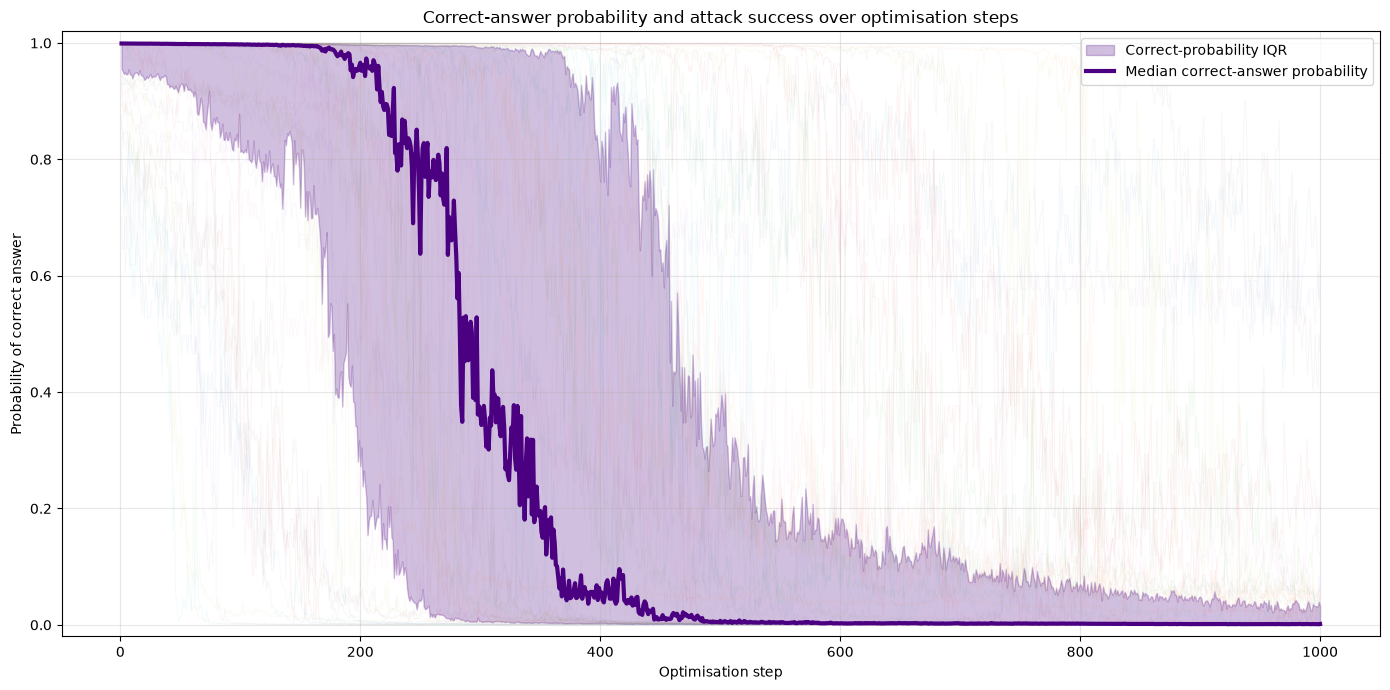

In [16]:
correct_probability_data = []

for question_id, sample_history in filtered_history.groupby("question_id"):
    sample_history = sample_history.sort_values("step").copy()

    sample = samples[question_id]
    correct_answer = sample["correct_answer"].upper()
    probability_column = f"prob_{correct_answer}"

    sample_probability = sample_history[
        ["question_id", "step", probability_column, "attack_success"]
    ].copy()

    sample_probability = sample_probability.rename(
        columns={probability_column: "correct_probability"}
    )

    correct_probability_data.append(sample_probability)

correct_probability_history = pd.concat(
    correct_probability_data,
    ignore_index=True,
)

probability_summary = (
    correct_probability_history
    .groupby("step")["correct_probability"]
    .agg(
        median="median",
        q1=lambda values: values.quantile(0.25),
        q3=lambda values: values.quantile(0.75),
    )
    .reset_index()
)

# Only evaluated rows are included in the success-rate calculation
success_summary = (
    correct_probability_history
    .dropna(subset=["attack_success"])
    .groupby("step")["attack_success"]
    .agg(
        successful="sum",
        evaluated="count",
    )
    .reset_index()
)

success_summary["success_rate"] = (
    success_summary["successful"]
    / success_summary["evaluated"]
)

fig, probability_axis = plt.subplots(figsize=(14, 7))

# Individual correct-answer trajectories
for question_id, sample_history in correct_probability_history.groupby(
    "question_id"
):
    probability_axis.plot(
        sample_history["step"],
        sample_history["correct_probability"],
        alpha=0.05,
        linewidth=0.7,
    )

# Correct-answer probability IQR
probability_axis.fill_between(
    probability_summary["step"],
    probability_summary["q1"],
    probability_summary["q3"],
    alpha=0.25,
    label="Correct-probability IQR",
    color="indigo"
)

# Median correct-answer probability
probability_axis.plot(
    probability_summary["step"],
    probability_summary["median"],
    linewidth=3,
    label="Median correct-answer probability",
    color="indigo"
)

probability_axis.set_xlabel("Optimisation step")
probability_axis.set_ylabel("Probability of correct answer")
probability_axis.set_ylim(-0.02, 1.02)
probability_axis.grid(alpha=0.3)

# # Attack success rate on a second y-axis
# success_axis = probability_axis.twinx()

# success_axis.plot(
#     success_summary["step"],
#     success_summary["success_rate"],
#     linestyle="--",
#     marker="o",
#     markersize=5,
#     linewidth=1.8,
#     label="Attack success rate",
#     color="royalblue"
# )

# success_axis.set_ylabel("Attack success rate")
# success_axis.set_ylim(-0.02, 1.02)

# # Combine legends from both axes
# probability_handles, probability_labels = (
#     probability_axis.get_legend_handles_labels()
# )
# success_handles, success_labels = (
#     success_axis.get_legend_handles_labels()
# )

# probability_axis.legend(
#     probability_handles + success_handles,
#     probability_labels + success_labels,
#     loc="best",
# )
probability_axis.legend()

probability_axis.set_title(
    "Correct-answer probability and attack success over optimisation steps"
)

fig.tight_layout()
plt.show()